In [5]:
import numpy as np
import pandas as pd
labels = np.load('data/labels/test_labels.npy')
gcl    = pd.read_csv('results/global_reconstruction_error.csv')
spc    = np.load('results/scores_spc.npy')
ifor   = np.load('results/scores_iforest.npy')
ocsvm  = np.load('results/scores_ocsvm.npy')
print(f'Labels         : {len(labels)} windows')
print(f'GCL scores     : {len(gcl)} rows')
print(f'SPC scores     : {len(spc)} windows')
print(f'IForest scores : {len(ifor)} windows')
print(f'OC-SVM scores  : {len(ocsvm)} windows')

Labels         : 1991 windows
GCL scores     : 299 rows
SPC scores     : 1991 windows
IForest scores : 1991 windows
OC-SVM scores  : 1991 windows


In [7]:
import pandas as pd
import numpy as np

gcl_old = pd.read_csv("results/global_reconstruction_error.csv")
print("global_reconstruction_error.csv:", len(gcl_old))

gcl_new = np.loadtxt("results/test_errors.csv", delimiter=",")
print("test_errors.csv:", len(gcl_new))

global_reconstruction_error.csv: 1991
test_errors.csv: 1991


In [2]:
import numpy as np, pandas as pd
labels = np.load('data/labels/test_labels.npy')
gcl    = pd.read_csv('results/global_reconstruction_error.csv')
n_gcl  = len(gcl)
n_lab  = len(labels)
match  = n_gcl == n_lab
print(f'Labels : {n_lab}')
print(f'GCL    : {n_gcl}')
print(f'Match  : {match}')
if not match:
    print('STOP — fix inference.py CSV path before running plot_curves.py')

Labels : 1991
GCL    : 1991
Match  : True


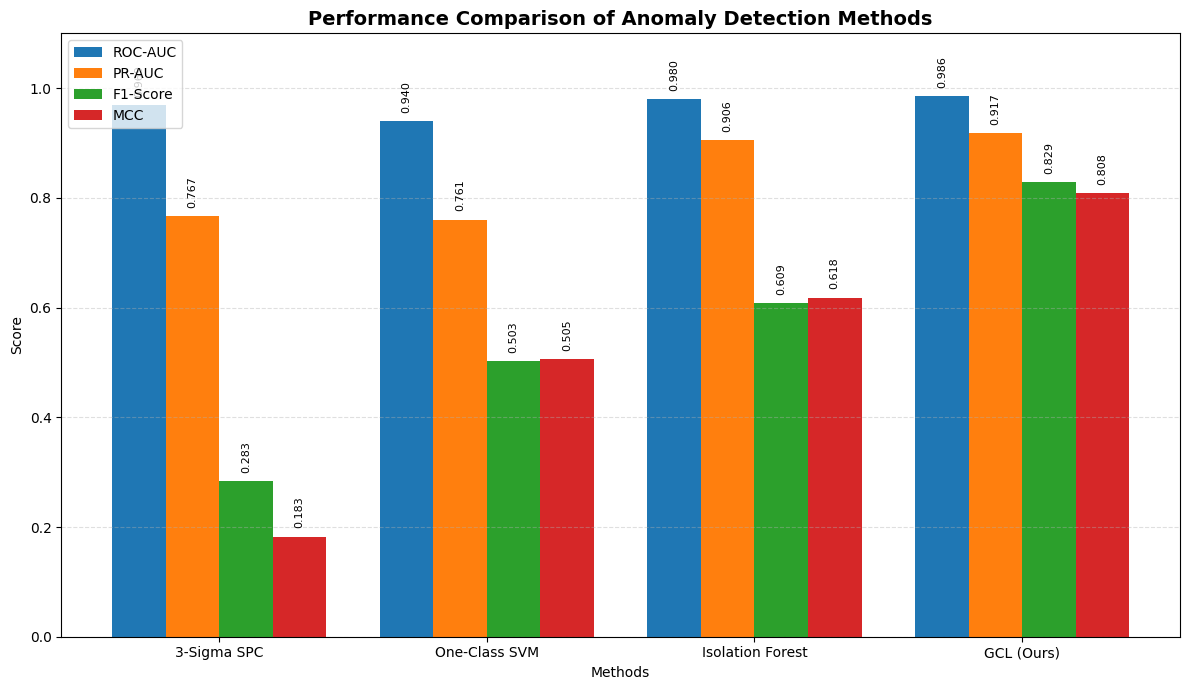

Saved: results/final_grouped_bar_chart.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Results
# ==========================
methods = [
    "3-Sigma SPC",
    "One-Class SVM",
    "Isolation Forest",
    "GCL (Ours)"
]

roc_auc = [0.9685, 0.9399, 0.9795, 0.9860]
pr_auc  = [0.7672, 0.7606, 0.9056, 0.9174]
f1      = [0.2832, 0.5026, 0.6085, 0.8286]
mcc     = [0.1827, 0.5054, 0.6184, 0.8082]

# ==========================
# Plot
# ==========================
x = np.arange(len(methods))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - 1.5*width, roc_auc, width,
               label='ROC-AUC')

bars2 = ax.bar(x - 0.5*width, pr_auc, width,
               label='PR-AUC')

bars3 = ax.bar(x + 0.5*width, f1, width,
               label='F1-Score')

bars4 = ax.bar(x + 1.5*width, mcc, width,
               label='MCC')

# --------------------------
# Formatting
# --------------------------
ax.set_ylabel("Score")
ax.set_xlabel("Methods")
ax.set_title(
    "Performance Comparison of Anomaly Detection Methods",
    fontsize=14,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(methods)

ax.set_ylim(0, 1.1)

ax.grid(axis='y',
        linestyle='--',
        alpha=0.4)

ax.legend(loc='upper left')

# --------------------------
# Value labels
# --------------------------
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f"{h:.3f}",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()

plt.savefig(
    "results/final_grouped_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: results/final_grouped_bar_chart.png")

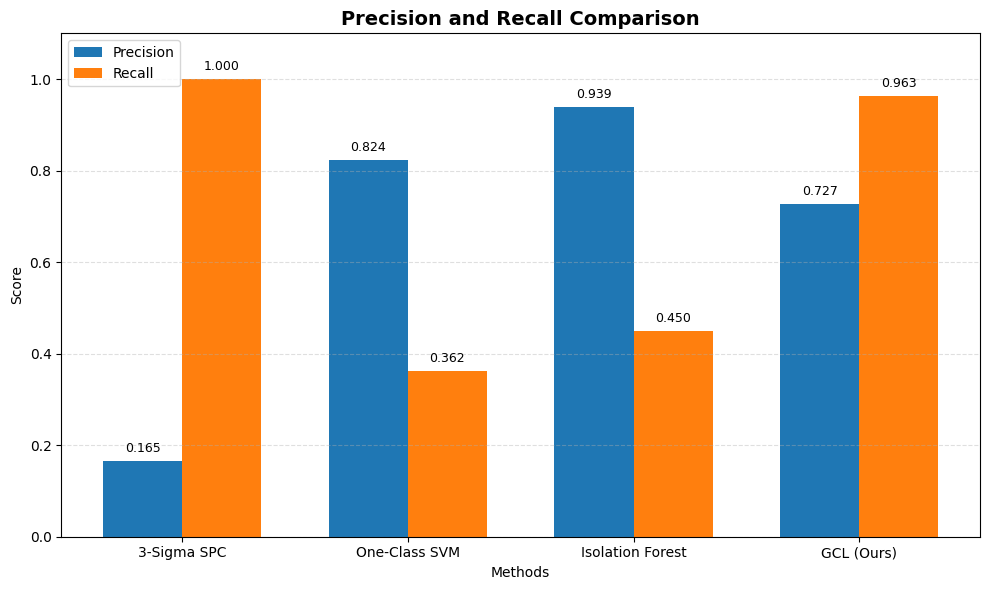

Saved: results/precision_recall_comparison.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

methods = [
    "3-Sigma SPC",
    "One-Class SVM",
    "Isolation Forest",
    "GCL (Ours)"
]

precision = [0.1649, 0.8235, 0.9385, 0.7270]
recall    = [1.0000, 0.3616, 0.4502, 0.9631]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    precision,
    width,
    label="Precision"
)

bars2 = ax.bar(
    x + width/2,
    recall,
    width,
    label="Recall"
)

ax.set_title(
    "Precision and Recall Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Score")
ax.set_xlabel("Methods")

ax.set_xticks(x)
ax.set_xticklabels(methods)

ax.set_ylim(0, 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

# Add values above bars
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "results/precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: results/precision_recall_comparison.png")

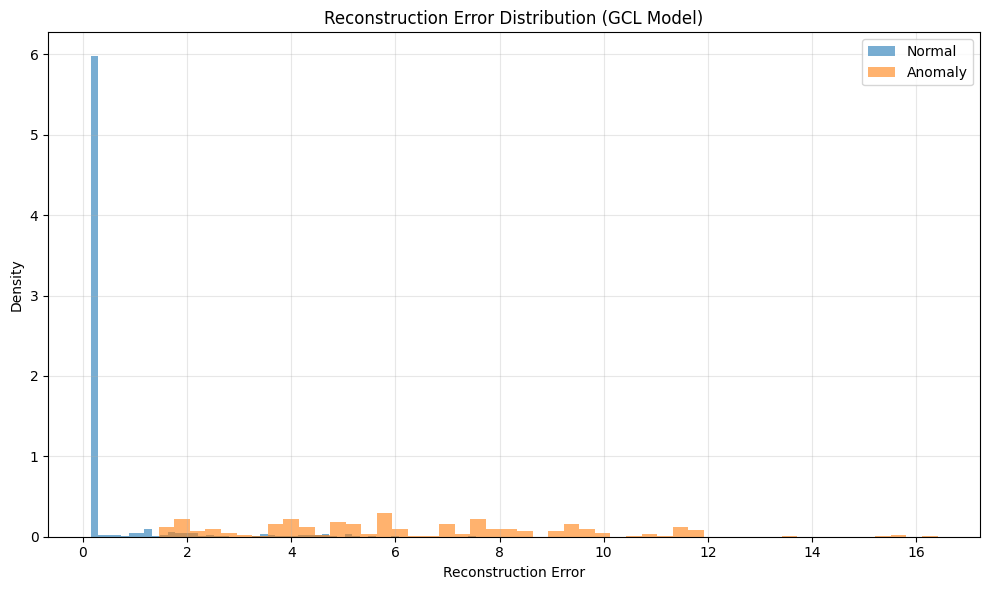

Saved: results/error_distribution.png


In [3]:
plot_error_distribution(gcl["global_reconstruction_error"].values, labels)